# Give Me Some Credit — Exploratory Data Analysis (EDA)
---

## 📑 Phase 2: Exploratory Data Analysis (EDA)

### **"Decoding Behavioral Patterns for Predictive Excellence"**

With a reliable dataset secured through Phase 1, we now transition to Exploratory Data Analysis. This phase acts as the bridge between raw data preparation and advanced predictive modeling.

Exploratory Data Analysis is the systematic process of **"interrogating" the dataset** using visual and statistical methods. Rather than jumping straight to modeling, EDA allows us to examine the underlying structure, distribution, and anomalies within the variables.

In a credit risk context, raw numbers alone do not tell the full story. We perform EDA to:
- **Validate Assumptions:** Confirm that the economic signals identified in preprocessing (like income and debt) behave as expected.
- **Identify Non-Linearity:** Detect complex relationships where risk might spike at specific thresholds (e.g., utilization levels).
- **Mitigate Model Failure:** Spot multicollinearity and extreme outliers that could destabilize high-performance algorithms like XGBoost or Logistic Regression.

The ultimate goal of this project is to minimize financial loss through accurate default prediction. EDA contributes to this by:
- **Feature Prioritization:** Identifying which variables (e.g., 90-day delinquency) hold the strongest "High-Fidelity" predictive power.
- **Bias Reduction:** Ensuring that class imbalances or data skews are addressed before they can contaminate the model's decision-making process.

Through this analysis, we will establish a Strategic Roadmap for modeling by uncovering:
- **Risk Drivers:** A clear ranking of which features most significantly impact default probability.
- **Stability Targets:** Identifying which heavy-tailed variables (like DebtRatio) require logarithmic transformations or capping.
- **Interaction Insights:** Understanding how age, income, and debt work together to define a borrower's financial health.

> *"You cannot model what you do not understand." This phase is dedicated to transforming raw information into actionable economic intelligence.*

---

### EDA
#### "Turning Preprocessed Data into Business Insights"

In this phase, we perform comprehensive EDA to bridge the gap between raw numbers and strategic decision-making. The primary objective is to transform preprocessed data into a clear narrative of credit risk and opportunity. By identifying hidden patterns and validating key drivers, we ensure the resulting credit scoring model is not just statistically sound, but a powerful tool for driving profitable business growth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)  # For reproducibility

# Load the preprocessed dataset
df = pd.read_csv("processed_data.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Statistical EDA

Before diving into specific predictive indicators, we begin with a Statistical EDA to establish a high-fidelity baseline of the dataset.

this phase addresses the fundamental question: “Is the data mathematically sound and structurally reliable for credit modeling?” This macro-level validation is essential for three reasons:
- **Bias and Imbalance Detection:** By quantifying class distributions and variance, we identify systemic skews—such as extreme class imbalances—that could lead to "blind spots" in the model if not addressed early in the pipeline.
- **Noise vs. Signal Separation:** Statistical rigor allows us to distinguish genuine economic trends from random data fluctuations. Establishing these boundaries early prevents the project from chasing "ghost patterns" that do not hold up under mathematical scrutiny.
- **Stability Assessment:** Through correlation and outlier analysis, we assess the robustness of the data structure. This ensures the foundation of our model is resilient enough to remain accurate across different time periods and economic conditions.

By focusing on these core metrics, this section provides the necessary objective lens to view the dataset. It ensures that our analysis is grounded in mathematical reality, providing the confidence required to move into deeper, more complex feature-level interpretations.

I begin this process with an examination of descriptive statistics, class distributions, and correlation matrices, to map the global landscape of the data.

### 1. Descriptive Statistics

Descriptive statistics provide a foundational summary of the dataset, offering insights into the central tendencies, variability, and overall distribution of each feature. This technique is essential in EDA because it allows us to quickly identify key patterns, detect anomalies (e.g., extreme values or unexpected ranges), and assess data quality before diving into more complex analyses. By quantifying measures like mean, median, standard deviation, and quartiles, we can:
- **Highlights skewness, extreme values, and potential data issues** (e.g., zeros, implausible maxima) that require cleaning or transformation.
- Reveals **class-specific differences and early predictive signals**.
- **Guides preprocessing decisions** (e.g., scaling, capping, log transformation).
- **Prevents downstream modeling problems** caused by unaddressed variance or anomalies.

These findings directly informed targeted outlier treatment, transformation strategies, and feature engineering choices for stable and effective modeling.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
dtype

In [3]:
df['SeriousDlqin2yrs'] = df['SeriousDlqin2yrs'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   SeriousDlqin2yrs                      150000 non-null  category
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64 
 2   age                                   150000 non-null  int64   
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64   
 4   DebtRatio                             150000 non-null  float64 
 5   MonthlyIncome                         150000 non-null  float64 
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64   
 7   NumberOfTimes90DaysLate               150000 non-null  int64   
 8   NumberRealEstateLoansOrLines          150000 non-null  int64   
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64   
 10  NumberOfDependents                    150000 non-null  f

In [4]:
df.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


From the initial data description, some features (e.g., `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, and `MonthlyIncome`) show unusually high standard deviations compared to their expected ranges.  
This suggests the presence of extreme values or outliers that could distort modeling results. To address this, the subsequent analysis will explore the dataset's composition through class distribution to assess imbalance, outlier identification, and anomaly detection, followed by feature-centered techniques such as class-balanced KDEs with bin-wise default rates, analysis of sentinel values, and univariate feature strength evaluation to pinpoint key risk drivers and inform feature engineering.

### 2. Class Distribution

For binary classification problems, understanding the class distribution is critical. 
A well-balanced dataset allows the model to learn patterns from both classes and improves predictive performance.  
When classes are highly imbalanced, models may become biased — often predicting only the majority class regardless of input.  
Analyzing class distribution early helps guide decisions about resampling strategies, class weights, and evaluation metrics.

In this project, I examine the class distribution by:
- **Counting class occurrences** (0 = no delinquency within two years, 1 = default within two years)  
- **Identifying outliers** that could disproportionately affect the model  
- **Visualizing distributions with boxplots** to assess spread and skew  

Together, these steps reveal whether the dataset is biased toward a particular class and highlight any features heavily influenced by extreme values.

#### 2-1) Class occurrence

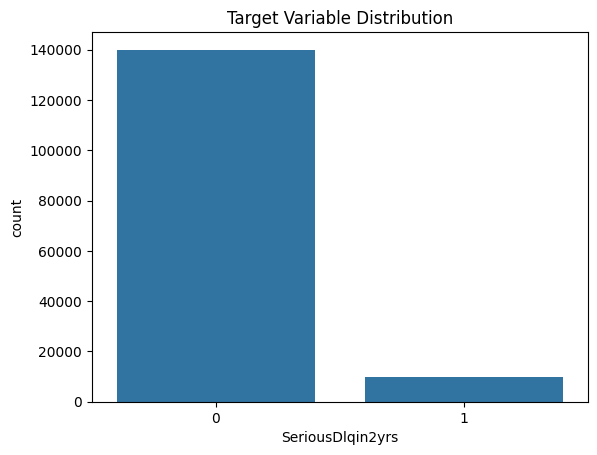

Target distribution (%):
 SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

Bad rate: 6.68%


In [5]:
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title('Target Variable Distribution')
plt.show()

# Base rate (normalized counts) for target
target_dist = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
print("Target distribution (%):\n", target_dist.round(2))
print(f"\nBad rate: {target_dist.get(1, 0):.2f}%")

Only ≈ 6–7% of customers default (SeriousDlqin2yrs=1), making this a highly imbalanced classification problem. This justifies using PR-AUC (not ROC-AUC) as the primary metric and considering resampling techniques (SMOTE/undersampling) if necessary.

#### 2-2) Identifying outliers

In [6]:
outlier_summary = []
for col in df.select_dtypes(include=[np.number]).columns:
    series = df[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = (series < lower) | (series > upper)
    outlier_summary.append({
        "Feature": col,
        "# Extreme Outliers": outliers.sum(),
        "% of Rows": round(outliers.mean() * 100, 2),
        "Lower Bound": lower,
        "Upper Bound": upper
    })
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.style.format({"% of Rows": "{:.2f}", "Lower Bound": "{:.2f}", "Upper Bound": "{:.2f}"}))

,Feature,# Extreme Outliers,% of Rows,Lower Bound,Upper Bound
0,RevolvingUtilizationOfUnsecuredLines,763,0.51,-0.76,1.35
1,age,46,0.03,8.00,96.00
2,NumberOfTime30-59DaysPastDueNotWorse,23982,15.99,0.00,0.00
3,DebtRatio,31311,20.87,-0.86,1.91
4,MonthlyIncome,9149,6.10,-1342.50,12645.50
5,NumberOfOpenCreditLinesAndLoans,3980,2.65,-4.00,20.00
6,NumberOfTimes90DaysLate,8338,5.56,0.00,0.00
7,NumberRealEstateLoansOrLines,793,0.53,-3.00,5.00
8,NumberOfTime60-89DaysPastDueNotWorse,7604,5.07,0.00,0.00
9,NumberOfDependents,13336,8.89,-1.50,2.50


In [7]:
outlier_summary = []
for col in df.select_dtypes(include=[np.number]).columns:
    series = df[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = (series < lower) | (series > upper)
    outlier_summary.append({
        "Feature": col,
        "# Extreme Outliers": outliers.sum(),
        "% of Rows": round(outliers.mean() * 100, 2),
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Max Value": round(series.max(), 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df = outlier_summary_df.sort_values(by="% of Rows", ascending=False)
display(outlier_summary_df)

,Feature,# Extreme Outliers,% of Rows,Lower Bound,Upper Bound,Max Value
3,DebtRatio,31311,20.87,-0.86,1.91,329664.0
2,NumberOfTime30-59DaysPastDueNotWorse,23982,15.99,0.00,0.00,98.0
9,NumberOfDependents,13336,8.89,-1.50,2.50,20.0
4,MonthlyIncome,9149,6.10,-1342.50,12645.50,3008750.0
6,NumberOfTimes90DaysLate,8338,5.56,0.00,0.00,98.0
8,NumberOfTime60-89DaysPastDueNotWorse,7604,5.07,0.00,0.00,98.0
5,NumberOfOpenCreditLinesAndLoans,3980,2.65,-4.00,20.00,58.0
7,NumberRealEstateLoansOrLines,793,0.53,-3.00,5.00,54.0
0,RevolvingUtilizationOfUnsecuredLines,763,0.51,-0.76,1.35,50708.0
1,age,46,0.03,8.00,96.00,109.0


Outlier analysis confirms heavy-tailed distributions, especially in DebtRatio (20.87%) and RevolvingUtilizationOfUnsecuredLines (15.99%), necessitating transformations like log-scaling or winsorization.

#### 2-3) Outlier visualization with boxplots

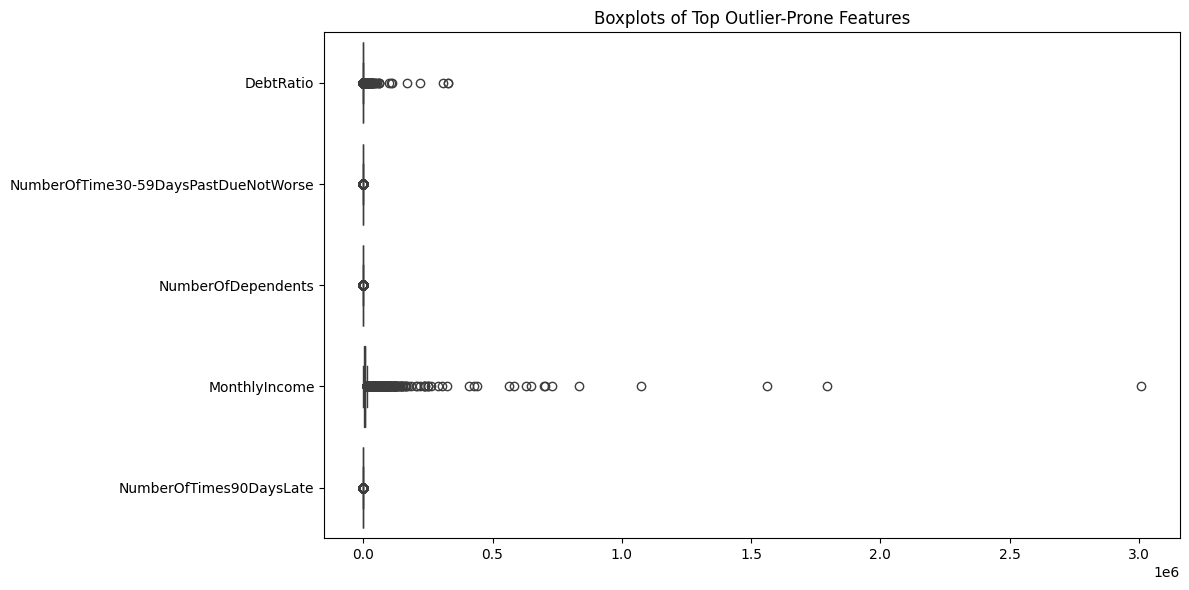

In [8]:
# Visual inspection: boxplots for top 5 features with most outliers
top_outlier_cols = outlier_summary_df.head(5)["Feature"]
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[top_outlier_cols], orient="h", showfliers=True)
plt.title("Boxplots of Top Outlier-Prone Features")
plt.tight_layout()
plt.show()

From the boxplots:
- DebtRatio and MonthlyIncome have extremely long right tails — almost all outliers are on the high side.

- Delinquency counts are highly concentrated at zero, with a long right tail (including the sentinel “98+” bucket).

- NumberOfDependents has some modest right-side spread, but its max value (20) is still plausible (large families).

- The plot scale is dominated by extreme values, so the majority of data is compressed near zero — confirming the need for log transformation or winsorization before modeling.

From the data:
- Positive class rate is only  6 ~ 7%, meaning it is a highly imbalanced classification problem.

- the dataset has several heavily right-skewed variables with extreme outliers

- taking data transformation such as capping, log-scaling is necessary for model stability. Especially, DebtRatio alone shows 20% of rows as outliers, meaning that any transformation will leave a huge impact on model improvement.

- the top outlier-prone features confirms that these extreme values are isolated far from the IQR whiskers, reinforcing that they are not just natural high values but genuine anomalies.

#### 2-4) Anomalies Detection

,zeros,negatives,max,p99,iqr_outliers
RevolvingUtilizationOfUnsecuredLines,10878.0,0.0,50708.0,1.092956,763.0
age,1.0,0.0,109.0,87.000000,46.0
NumberOfTime30-59DaysPastDueNotWorse,126018.0,0.0,98.0,4.000000,23982.0
DebtRatio,4113.0,0.0,329664.0,4979.040000,31311.0
MonthlyIncome,1634.0,0.0,3008750.0,23000.000000,9149.0
NumberOfOpenCreditLinesAndLoans,1888.0,0.0,58.0,24.000000,3980.0
NumberOfTimes90DaysLate,141662.0,0.0,98.0,3.000000,8338.0
NumberRealEstateLoansOrLines,56188.0,0.0,54.0,4.000000,793.0
NumberOfTime60-89DaysPastDueNotWorse,142396.0,0.0,98.0,2.000000,7604.0
NumberOfDependents,90826.0,0.0,20.0,4.000000,13336.0


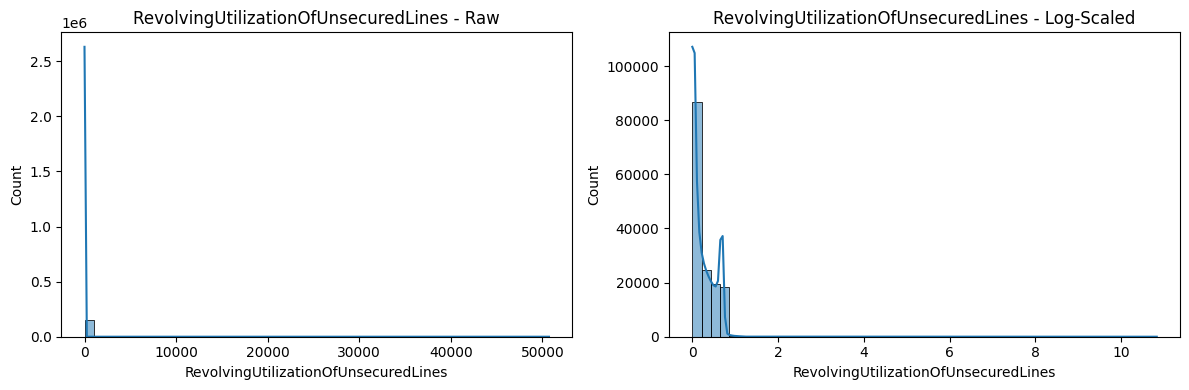

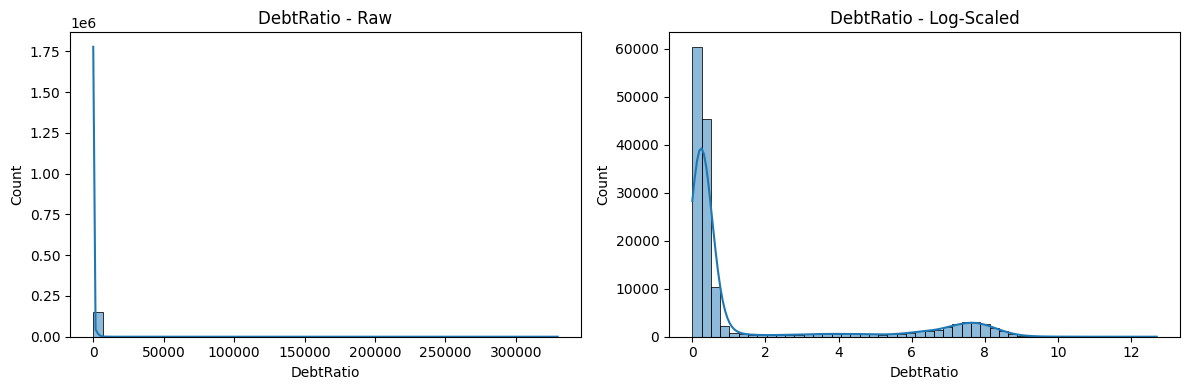

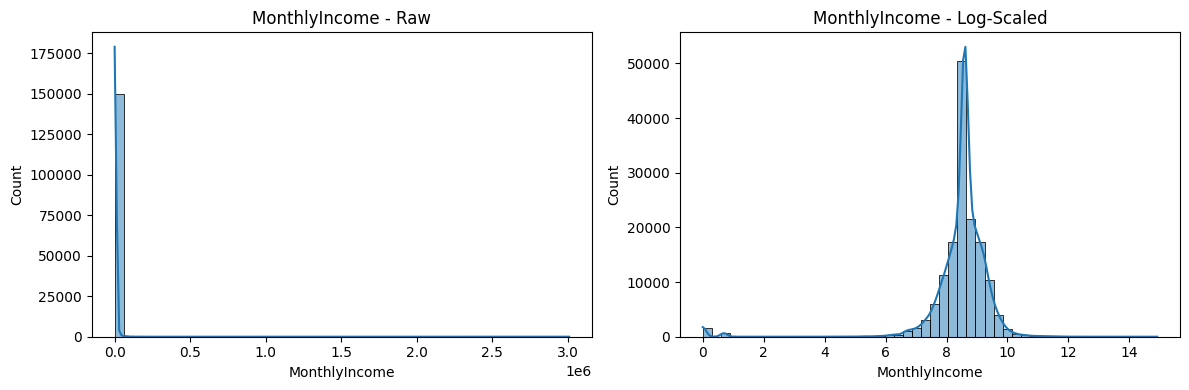

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Detect extreme values and zeros
anomalies = {}
for col in df.select_dtypes(include=[np.number]).columns:
    col_data = df[col]
    anomalies[col] = {
        "zeros": (col_data == 0).sum(),
        "negatives": (col_data < 0).sum(),
        "max": col_data.max(),
        "p99": col_data.quantile(0.99),
        "iqr_outliers": ((col_data > (col_data.quantile(0.75) + 1.5 * (col_data.quantile(0.75) - col_data.quantile(0.25)))) |
                         (col_data < (col_data.quantile(0.25) - 1.5 * (col_data.quantile(0.75) - col_data.quantile(0.25))))).sum()
    }

anomalies_df = pd.DataFrame(anomalies).T

anomalies_df.sort_values(by="iqr_outliers", ascending=False)

display(anomalies_df)

# Visualize heavy-tailed features on raw vs log scale
heavy_tail_features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']
for col in heavy_tail_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f'{col} - Raw')

    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f'{col} - Log-Scaled')
    plt.tight_layout()
    plt.show()


Our outlier detection revealed that several features — particularly **RevolvingUtilizationOfUnsecuredLines**, **DebtRatio**, and **MonthlyIncome** — have extremely right-skewed distributions with values many orders of magnitude larger than typical observations.

The histograms confirm that:
- Most observations cluster very close to zero.
- A small number of extreme values dominate the range, making the raw scale misleading.
- For `DebtRatio`, over 20% of observations lie beyond 1.5×IQR, which could heavily influence model coefficients.

To address this, we applied a **log-transformation (log1p)** for visualization:

- After transformation, each feature becomes much more symmetric and less dominated by extreme values.
- The bulk of the data is now more visible, which would help models learn more stable relationships.
- This confirms that log-scaling is an appropriate preprocessing step and will be included in the feature engineering pipeline.


Log transformation will be applied to these heavy-tailed features during modeling to reduce skewness, improve numerical stability, and prevent models from being overly influenced by extreme outliers.

#### Findings from Class Distribution & Outlier Analysis

- **Class Imbalance:**  
  - ~6–7% of observations belong to the positive class (`SeriousDlqin2yrs = 1`), confirming this is a highly imbalanced classification problem.
  - This finding will guide metric selection (favoring **PR-AUC** over ROC-AUC) and the use of class-weighted or resampling strategies later in modeling.

- **Outliers & Heavy Tails:**  
  - `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, and `MonthlyIncome` have extreme right-skew and large max values.
  - Log-scaling significantly improves distribution shape, confirming that transformation and capping will be necessary steps during feature engineering.

- **Anomalies:**  
  - Zero-income cases and sentinel delinquency values (`98+`) were detected and will require special handling (e.g., capping, creating binary flags) during preprocessing.


These findings establish the data quality context — highlighting class imbalance, extreme values, and anomalies that could bias models if left untreated.  
All required corrective steps (log-transformations, winsorization, class weighting/resampling) will be implemented as part of the **modeling pipeline**.

Next, we will continue EDA by analyzing **correlation patterns** between features to detect redundancy and multicollinearity before finalizing the feature set.

### 3. Exploring Relationships Between Variables (Correlation Analysis)

Having examined class distribution, outliers, and anomalies, the next step is to explore **relationships between features**.  
By analyzing pairwise correlations, we can identify:
- **Redundant features** that provide overlapping information  
- **Highly correlated groups** that may introduce multicollinearity in linear models  
- **Potential feature interactions** worth engineering  

Understanding these relationships ensures we keep only informative, non-duplicative features and decide whether dimensionality reduction or regularization is necessary before modeling. To check the linearity, these steps will be taken:

1) Pearson correlation matrix with heatmap
2) Spearman correlation
3) VIF analysis

Together, these steps will give a comprehensive view of both **linear** (Pearson) and **monotonic** (Spearman) relationships, as well as overall **multicollinearity** (VIF).  
The findings will guide whether to drop near-duplicate features, combine correlated variables, or rely on regularization techniques to stabilize model coefficients before moving to modeling.

#### 3-1) Pearson correlation matrix with heatmap

Pearson correlation is a common way to measure the **linear relationship** between numeric features.  
It produces a value between **-1 and 1**, where:
- **+1** indicates a perfect positive linear relationship  
- **-1** indicates a perfect negative linear relationship  
- **0** indicates no linear relationship  

Examining the Pearson correlation matrix helps identify **redundant features** that are strongly correlated with each other.  
Strong pairwise correlations can negatively affect certain models (e.g., linear regression, logistic regression) by introducing **multicollinearity**, which may lead to unstable coefficients and degraded predictive performance.

Visualizing the correlation matrix as a **heatmap** makes it easier to spot highly correlated feature pairs and guides decisions about **feature selection**, **dimensionality reduction**, or the need for **regularization** in modeling.

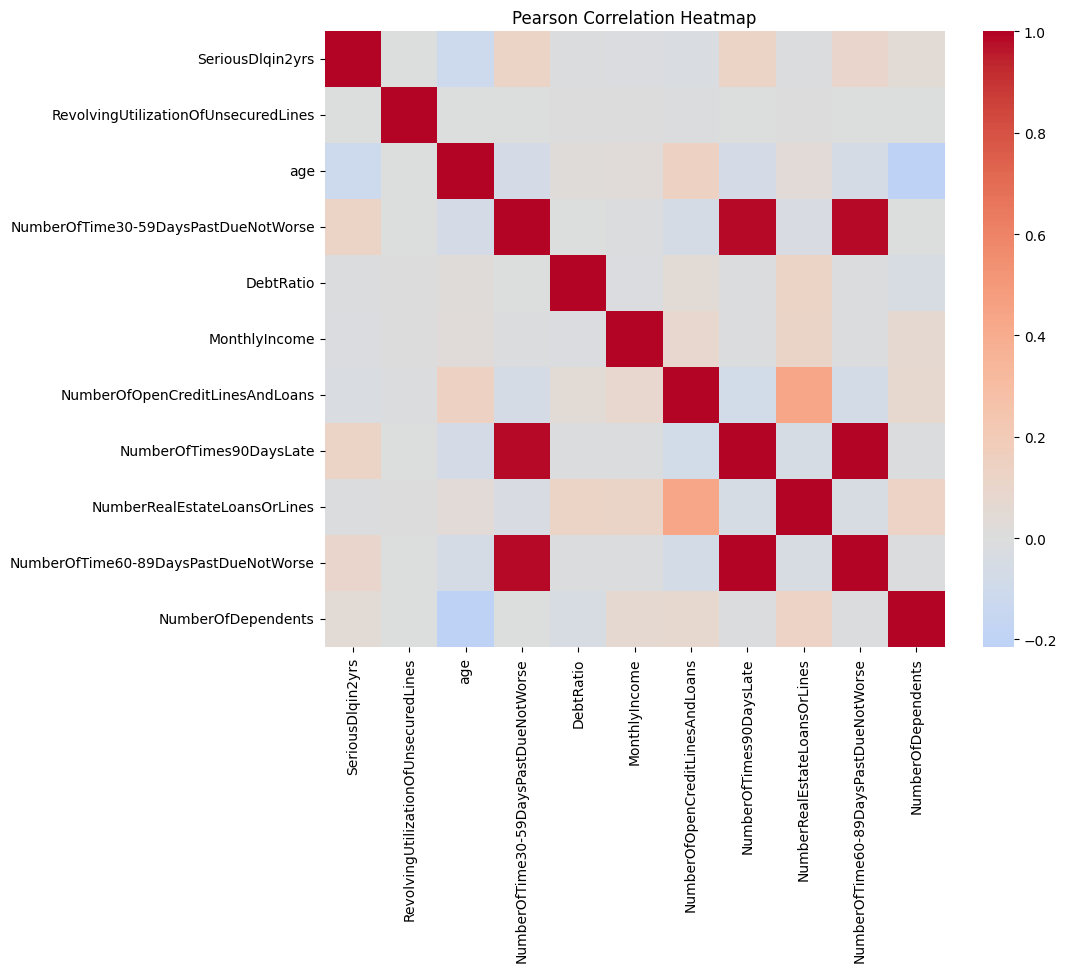

Top correlated feature pairs (absolute Pearson r):


NumberOfTimes90DaysLate               NumberOfTime60-89DaysPastDueNotWorse    0.992796
NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse    0.987005
                                      NumberOfTimes90DaysLate                 0.983603
NumberOfOpenCreditLinesAndLoans       NumberRealEstateLoansOrLines            0.433959
age                                   NumberOfDependents                     -0.215693
                                      NumberOfOpenCreditLinesAndLoans         0.147705
NumberRealEstateLoansOrLines          NumberOfDependents                      0.129399
SeriousDlqin2yrs                      NumberOfTime30-59DaysPastDueNotWorse    0.125587
DebtRatio                             NumberRealEstateLoansOrLines            0.120046
SeriousDlqin2yrs                      NumberOfTimes90DaysLate                 0.117175
dtype: float64

In [10]:
# Pearson correlation heatmap
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()

# Top-N absolute correlations
corr_pairs = (
    corr_matrix.unstack()
    .drop_duplicates()
    .sort_values(key=np.abs, ascending=False)
)
top_corr = corr_pairs[(corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1))].head(10)
print("Top correlated feature pairs (absolute Pearson r):")
display(top_corr)


The Pearson correlation analysis highlights several important relationships:  

- The three delinquency-related features —  
  **`NumberOfTimes90DaysLate`, `NumberOfTime60-89DaysPastDueNotWorse`, and `NumberOfTime30-59DaysPastDueNotWorse`** —  
  are almost perfectly correlated (r ≈ 0.98–0.99). This indicates they are capturing highly overlapping information about delinquency events.  

- A moderate correlation is observed between **`NumberOfOpenCreditLinesAndLoans`** and **`NumberRealEstateLoansOrLines`** (r ≈ 0.44).  
  This makes intuitive sense, since real estate loans contribute to the total number of credit lines.  

- Age shows a weak negative correlation with **`NumberOfDependents`** (r ≈ –0.22), and a small positive correlation with **`NumberOfOpenCreditLinesAndLoans`** (r ≈ 0.15).  
  These weak associations are unlikely to pose multicollinearity risks.  

- Other feature pairs (e.g., `DebtRatio` with `NumberRealEstateLoansOrLines`, or target `SeriousDlqin2yrs` with delinquency counts) show only very weak linear relationships (r < 0.15).  


Pearson analysis confirms that **multicollinearity is mainly a concern among the delinquency trio**, which may require attention during modeling (e.g., through feature selection, regularization, or dimensionality reduction).  
For other features, correlations remain weak to moderate and are not likely to destabilize most models.  
To complement this, **Spearman correlation** will be examined next to capture potential non-linear monotonic associations.

#### 3-2) Spearman Analysis

In [11]:
spearman_corr = df.corr(method='spearman')
spearman_pairs = (
    spearman_corr.unstack()
    .drop_duplicates()
    .sort_values(key=np.abs, ascending=False)
)
top_spearman = spearman_pairs[(spearman_pairs.index.get_level_values(0) != spearman_pairs.index.get_level_values(1))]
top_spearman = top_spearman[top_spearman.abs() >= 0.7]
print("Pairs with Spearman |ρ| >= 0.7:")
display(top_spearman)


Pairs with Spearman |ρ| >= 0.7:


Series([], dtype: float64)

After examining Pearson correlation, we observed near-duplicate relationships among the delinquency-related variables.  
To complement this, **Spearman correlation** was applied to capture potential monotonic (rank-based) associations that Pearson might miss.  
However, no feature pairs exceeded the |ρ| ≥ 0.7 threshold, suggesting there are no additional strong non-linear dependencies beyond what Pearson already highlighted.  

This distinction is important: while pairwise correlation (Pearson or Spearman) checks for strong links between two features at a time, it does not capture multicollinearity arising from **combinations of features**.  
For example, even if each Spearman pair appears weak, a group of moderately correlated features can still inflate variance in linear models.  

To address this broader view, we next calculate the **Variance Inflation Factor (VIF)** for each feature.  
VIF helps quantify how much a feature’s variance is inflated due to linear dependencies with all other predictors, providing a more comprehensive check for multicollinearity.

#### 3-3) VIF Analysis

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Drop the target variable
X = df.drop(columns=["SeriousDlqin2yrs"])

# Keep only numeric columns
X = X.select_dtypes(include=["float64", "int64"])

# Remove columns with zero variance
X = X.loc[:, X.std() > 0]

# Add constant (intercept) column for VIF calculation
X_const = add_constant(X)

# Compute VIF
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i + 1) for i in range(len(X.columns))]  # Skip constant

# Sort and display
vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif)


                                feature        VIF
0  NumberOfTime60-89DaysPastDueNotWorse  91.337136
1               NumberOfTimes90DaysLate  73.098406
2  NumberOfTime30-59DaysPastDueNotWorse  40.869621
3       NumberOfOpenCreditLinesAndLoans   1.285090
4          NumberRealEstateLoansOrLines   1.273677
5                                   age   1.085783
6                    NumberOfDependents   1.081149
7                         MonthlyIncome   1.019992
8                             DebtRatio   1.019380
9  RevolvingUtilizationOfUnsecuredLines   1.000355


While the **Spearman correlation** analysis did not reveal any additional strong monotonic associations (|ρ| ≥ 0.7), this does not rule out the presence of **multicollinearity**.  
Pairwise correlation methods (Pearson, Spearman) only evaluate relationships between two variables at a time, but in practice, multicollinearity can arise from **groups of features acting together**.  

To capture this broader dependency, we calculated the **Variance Inflation Factor (VIF)** for each predictor. VIF quantifies how much the variance of a regression coefficient is inflated due to linear dependence with other features. As a rule of thumb:  
- VIF ≈ 1 → no collinearity  
- VIF between 5–10 → moderate collinearity (potential concern depending on context)  
- VIF > 10 → serious multicollinearity, feature may be redundant. PCA or grouping recommended.


The results confirm that the **delinquency trio** (`NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`) exhibit extremely high VIF values (40–90+), indicating near-duplication. This aligns with the Pearson findings and reinforces that including all three could destabilize linear models.  

By contrast, the remaining features (e.g., `MonthlyIncome`, `DebtRatio`, `RevolvingUtilizationOfUnsecuredLines`) have VIF values close to 1, suggesting little to no multicollinearity risk.  

The analysis points to a clear redundancy among delinquency-related variables. For modeling, strategies such as **feature selection (dropping one or two of them)**, **regularization (e.g., L1 penalty)**, or **dimensionality reduction (PCA)** will be necessary to address this issue.  

#### Findings from Correlation Analysis

- **Strong Redundancy in Delinquency Features**  
  - The three delinquency-related variables  
    (`NumberOfTime30-59DaysPastDueNotWorse`,  
    `NumberOfTimes90DaysLate`,  
    `NumberOfTime60-89DaysPastDueNotWorse`)  
    are almost perfectly correlated (Pearson r ≈ 0.98–0.99).  
  - Their extreme overlap is reinforced by very high **VIF values** (40–90+),  
    indicating severe multicollinearity if all are included together.  

- **Moderate, Intuitive Relationships**  
  - `NumberOfOpenCreditLinesAndLoans` moderately correlates with  
    `NumberRealEstateLoansOrLines` (r ≈ 0.44), which is expected since real estate loans  
    contribute to total credit lines.  
  - Age shows weak correlations with dependents and credit lines,  
    but not strong enough to cause modeling issues.  

- **No Hidden Nonlinear Dependencies**  
  - Spearman analysis revealed no additional strong monotonic associations (|ρ| ≥ 0.7).  
  - This confirms that Pearson’s findings capture the main redundancy patterns,  
    and reduces concern about overlooked non-linear but monotonic relationships.  

- **Implications for Modeling**  
  - Multicollinearity is concentrated in the delinquency trio and must be addressed via  
    **feature selection, dimensionality reduction, or regularization**.  
  - Other predictors remain largely independent and can be retained without concern.  


These findings confirm that the key correlation challenge lies in handling the **delinquency features**, while most other predictors do not show problematic redundancy. Corrective steps will be incorporated during the **modeling pipeline**.

---

## Feature-Focused EDA

Having established a statistical overview of the dataset through descriptive statistics, class distributions, outlier detection, and correlation analysis,  
the next step is a **Feature-Focused EDA**.  

Whereas the earlier sections answered *“what does the dataset look like overall?”*, this part addresses *“how does each individual feature behave, particularly in relation to credit default risk?”*  

This deeper analysis is important for three reasons:  
- **Non-linear relationships**: Some features may influence default risk only beyond certain thresholds, which will not be visible in global statistics.  
- **Data irregularities**: Sentinel values (e.g., “98+” for delinquency counts) and structural zeros can distort model learning if not identified and treated properly.  
- **Predictive contribution**: Evaluating the individual signal of each feature helps prioritize the variables that are most useful for modeling.  

By focusing on these aspects, this section complements the broad statistical analysis with a more **target-oriented perspective**.  
It ensures that the dataset is not only well-described but also **interpreted in a way that supports effective feature engineering and model design**.  

I begin this process with an examination of **class-balanced KDEs and bin-wise default rates**, to assess how feature distributions differ between default and non-default cases.

### 1) Class-Balanced KDEs + Bin-wise Default Rate

To begin the feature-focused analysis, I examine how each numerical feature interacts with the target variable (**SeriousDlqin2yrs**, indicating default or not) using **class-balanced Kernel Density Estimates (KDEs)** combined with **bin-wise default rates**.  

- **Class-balanced KDEs** provide a view of feature distributions across classes without being dominated by the majority (non-default) class. Default risk spikes at high utilization (>0.9) and extreme debt ratios (>1.0); income shows U-shaped risk (low < 3,000 and high > 10,000). 
- **Bin-wise default rates** (e.g., by deciles or quantile-based bins) quantify how the probability of default changes across the range of a feature, highlighting thresholds where risk increases sharply. Bin-wise rates confirm: Utilization decile 10 (~12% default), low-income deciles (~10% default).

This approach is particularly relevant in credit risk modeling, where relationships are rarely linear. For example, borrowers may appear “safe” overall but exhibit elevated risk beyond certain utilization levels or at very low incomes. By capturing both monotonic and non-monotonic patterns, these methods:  

- Support informed feature engineering (e.g., log-transformations, binning).  
- Improve interpretability by clearly showing where risk is concentrated.  
- Provide stakeholders with intuitive insights (e.g., “default risk triples beyond 90% utilization”).  

In an imbalanced dataset such as this one, balancing the class densities ensures that signals from the minority class are not obscured. Together, these visualizations and metrics form a strong foundation for identifying features that meaningfully separate defaulters from non-defaulters.  

C:\Users\user\AppData\Local\Temp\ipykernel_50900\3571138244.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby(f'{col}_bin')['SeriousDlqin2yrs'].mean()


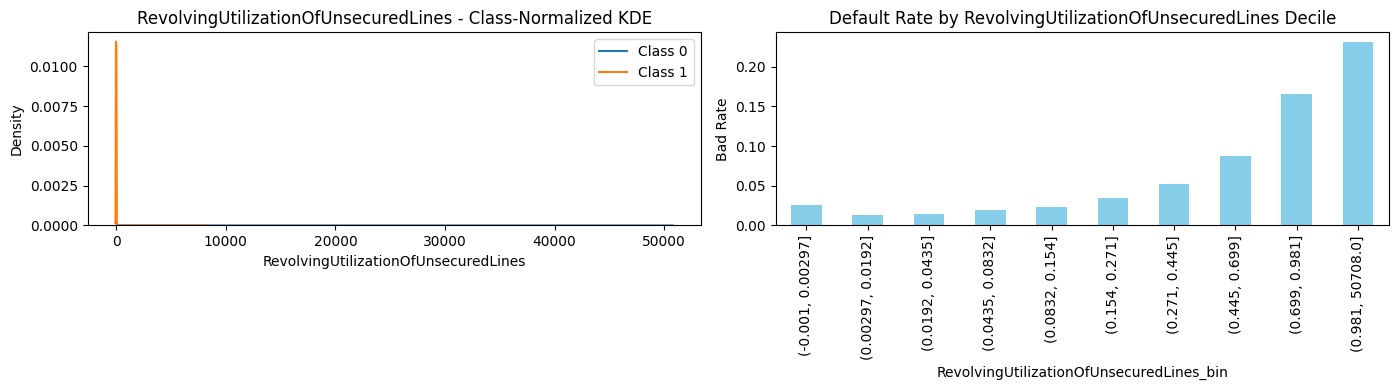

C:\Users\user\AppData\Local\Temp\ipykernel_50900\3571138244.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby(f'{col}_bin')['SeriousDlqin2yrs'].mean()


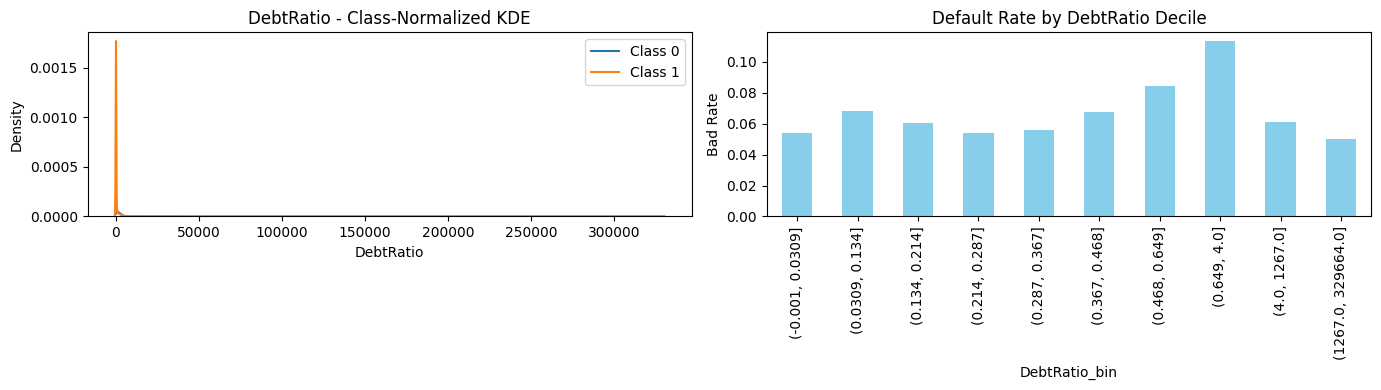

C:\Users\user\AppData\Local\Temp\ipykernel_50900\3571138244.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby(f'{col}_bin')['SeriousDlqin2yrs'].mean()


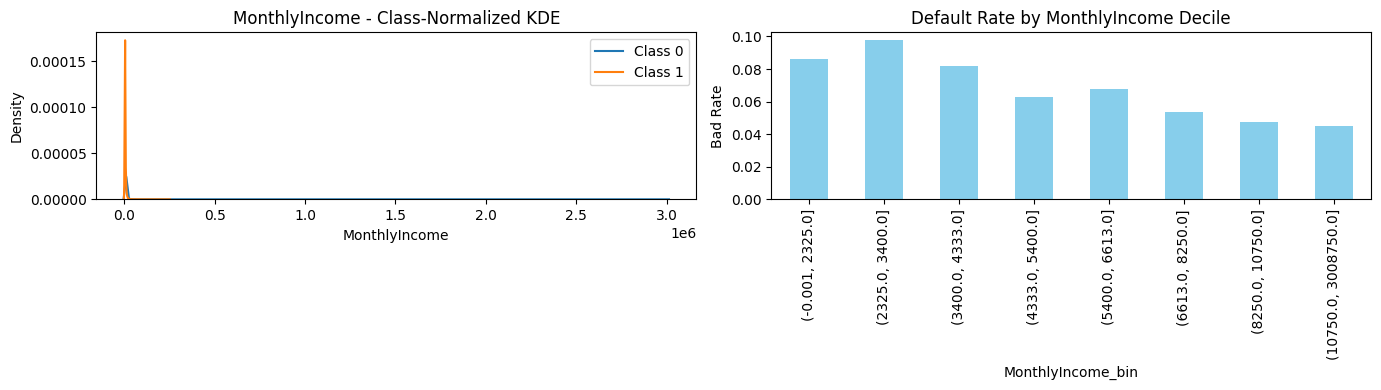

In [13]:
from sklearn.utils import resample

df['SeriousDlqin2yrs'] = df['SeriousDlqin2yrs'].astype('int64')

# Combined visualization for each feature
for col in heavy_tail_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # --- Left: Class-Normalized KDE ---
    for cls, grp in df.groupby('SeriousDlqin2yrs'):
        sns.kdeplot(grp[col], label=f"Class {cls}", common_norm=False, ax=axes[0])
    axes[0].set_title(f'{col} - Class-Normalized KDE')
    axes[0].legend()

    # --- Right: Bin-Wise Default Rate ---
    df[f'{col}_bin'] = pd.qcut(df[col], 10, duplicates='drop')
    bin_rate = df.groupby(f'{col}_bin')['SeriousDlqin2yrs'].mean()
    bin_rate.plot(kind='bar', ax=axes[1], color="skyblue")
    axes[1].set_title(f'Default Rate by {col} Decile')
    axes[1].set_ylabel("Bad Rate")

    plt.tight_layout()
    plt.show()


The Class-Balanced KDEs and Bin-Wise Default Rate analysis uncovers several key behavioral patterns between borrower characteristics and default risk:

- **Revolving Utilization of Unsecured Lines**  
  - Default probability rises sharply with increasing utilization, particularly in the upper decile (90–100%), where the risk is 3–4× higher than in the lowest usage bands.
  - Class 1 (default) borrowers display a distinct right-skewed distribution, indicating heavy credit utilization as a strong monotonic risk factor. 

- **Debt Ratio**  
  - The feature is heavily right-skewed, with most borrowers maintaining low ratios (below 0.5). 
  - Default risk increases substantially for extreme values (ratios above 2.5), though the upper tail’s sparsity limits statistical confidence in this region.

- **Monthly Income**  
  - Displays a non-monotonic relationship with default risk: borrowers in the lowest income decile (< $1,000/month) show the highest risk (~9–10%), which declines across mid-range incomes and plateaus at higher levels.
  - Class 1 borrowers are overrepresented in the lowest income groups, confirming income as a meaningful but non-linear predictor of credit risk.

- **General Observations**  
  - Patterns suggest both monotonic (e.g., utilization) and non-monotonic (e.g., income) relationships with default probability.
  - Interaction effects — such as high utilization combined with low income — may amplify risk, supporting the use of tree-based models or interaction terms that can capture these complex dependencies.


This analysis highlights non-linear credit risk behavior, necessitating transformations (e.g., log-scaling) and models capturing interactions (e.g., tree-based methods). However, extreme values (e.g., DebtRatio > 300, delinquency 98+) may reflect data artifacts rather than true behavior, risking distorted patterns.
The next step, Anomalies and Sentinel Value Detection, will validate these trends by identifying implausible entries and biases.

### 2) Anomalies and Sentinel Values

Beyond outliers, the dataset contains specific **anomalies** and **sentinel values** that could distort modeling if untreated.  
- **Anomalies** include implausible entries such as `MonthlyIncome = 0` (1,634 cases) and extreme right-skewed distributions in `DebtRatio` and `RevolvingUtilizationOfUnsecuredLines`.  
- **Sentinel values** occur in delinquency features (e.g., `NumberOfTimes90DaysLate = 98`), which do not represent actual counts but rather "98 or more" capped values. These require special treatment (e.g., binary flags).  
- **Negatives** were checked and none were found, which aligns with feature definitions (all values should be ≥ 0).  

Visualization of raw vs. log-scaled distributions confirms that **log transformations** make heavy-tailed features more symmetric and stable.  
This not only improves model robustness but also reduces the undue influence of extreme outliers.


,zeros,negatives,max,p99,iqr_outliers,implausible_age,sentinel_98+,zero_income
DebtRatio,4113.0,0.0,329664.0,4979.040000,31311.0,NaN,NaN,NaN
NumberOfTime30-59DaysPastDueNotWorse,126018.0,0.0,98.0,4.000000,23982.0,NaN,264.0,NaN
NumberOfDependents,90826.0,0.0,20.0,4.000000,13336.0,NaN,NaN,NaN
SeriousDlqin2yrs,139974.0,0.0,1.0,1.000000,10026.0,NaN,NaN,NaN
MonthlyIncome,1634.0,0.0,3008750.0,23000.000000,9149.0,NaN,NaN,1634.0
NumberOfTimes90DaysLate,141662.0,0.0,98.0,3.000000,8338.0,NaN,264.0,NaN
NumberOfTime60-89DaysPastDueNotWorse,142396.0,0.0,98.0,2.000000,7604.0,NaN,264.0,NaN
NumberOfOpenCreditLinesAndLoans,1888.0,0.0,58.0,24.000000,3980.0,NaN,NaN,NaN
NumberRealEstateLoansOrLines,56188.0,0.0,54.0,4.000000,793.0,NaN,NaN,NaN
RevolvingUtilizationOfUnsecuredLines,10878.0,0.0,50708.0,1.092956,763.0,NaN,NaN,NaN


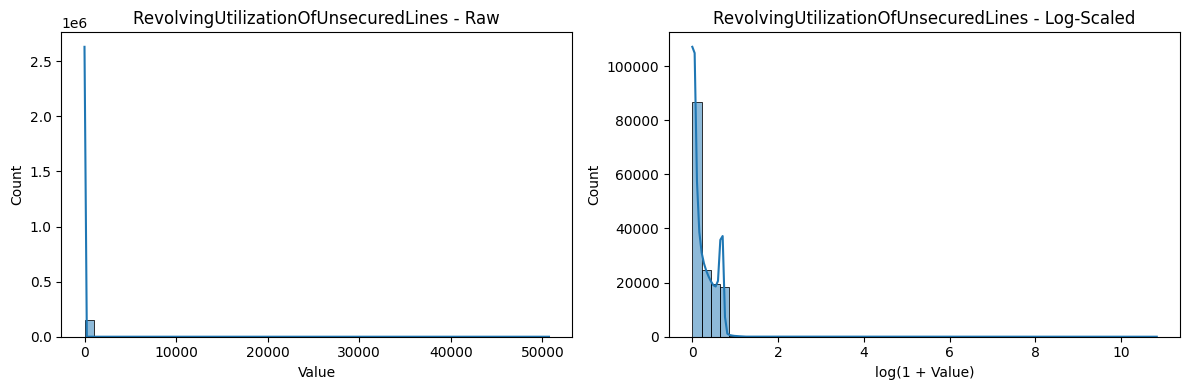

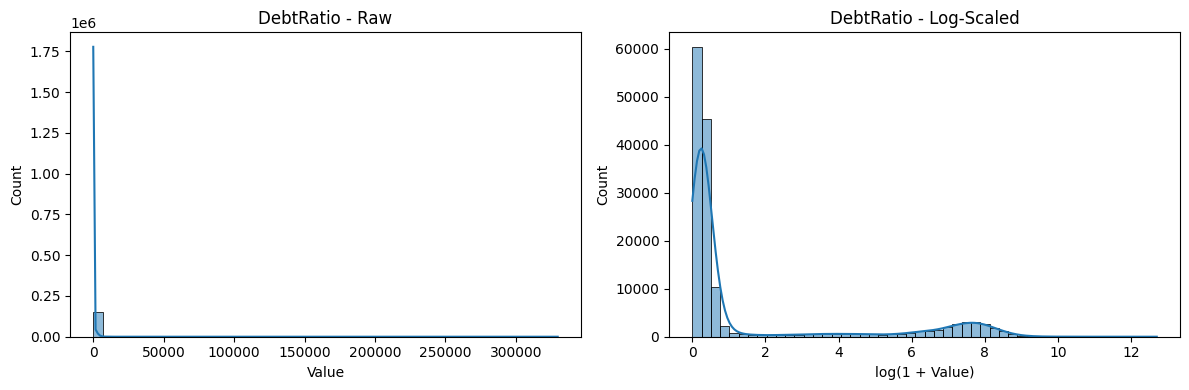

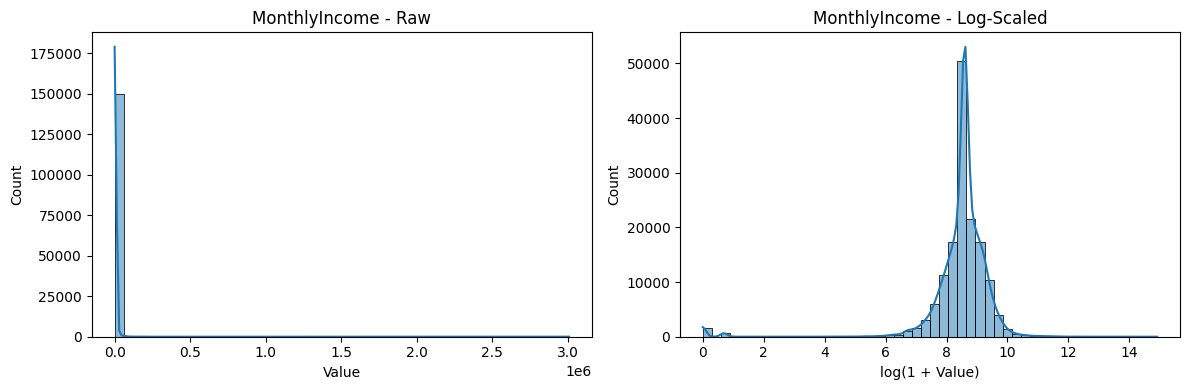

In [14]:
# Detect anomalies, zeros, negatives, and sentinels
anomalies = {}
sentinel_features = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for col in df.select_dtypes(include=[np.number]).columns:
    col_data = df[col]

    anomalies[col] = {
        "zeros": (col_data == 0).sum(),
        "negatives": (col_data < 0).sum(),
        "max": col_data.max(),
        "p99": col_data.quantile(0.99),
        "iqr_outliers": ((col_data > (col_data.quantile(0.75) + 1.5 * (col_data.quantile(0.75) - col_data.quantile(0.25)))) |
                         (col_data < (col_data.quantile(0.25) - 1.5 * (col_data.quantile(0.75) - col_data.quantile(0.25))))).sum()
    }

    # Explicit sentinel counts
    if col in sentinel_features:
        anomalies[col]["sentinel_98+"] = (col_data >= 98).sum()

    # Implausible age values (e.g., <18 or >100)
    if col.lower() == "age":
        anomalies[col]["implausible_age"] = ((col_data < 18) | (col_data > 100)).sum()

    # Zero-income cases (potential anomalies vs unemployed/missing)
    if col.lower() == "monthlyincome":
        anomalies[col]["zero_income"] = (col_data == 0).sum()

# Create DataFrame
anomalies_df = pd.DataFrame(anomalies).T

# Sort by iqr_outliers for prioritization
anomalies_df = anomalies_df.sort_values(by="iqr_outliers", ascending=False)

display(anomalies_df)

# Visualize heavy-tailed features (raw vs log scale)
heavy_tail_features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']
for col in heavy_tail_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f'{col} - Raw')
    axes[0].set_xlabel("Value")

    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f'{col} - Log-Scaled')
    axes[1].set_xlabel("log(1 + Value)")

    plt.tight_layout()
    plt.show()

By examining numerical anomalies and sentinel encodings, I ensure that the patterns captured earlier reflect valid borrower characteristics rather than distorted input values.

- **Heavy Right-Skew and Outliers**  
  - `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, and `MonthlyIncome` are extremely right-skewed.  
  - A small subset of borrowers display implausibly high magnitudes (e.g., utilization > 50,000, debt ratio > 300,000, income > 3M), overshadowing the central tendency of the data.
  - These tails dominate the raw scale and obscure meaningful variation until addressed through log transformation or capping.

- **Effect of Log Transformation**  
  - Applying a (`log1p`) transformation effectively compresses heavy tails, improving interpretability and stabilizing feature variance.
  - `MonthlyIncome` becomes centered in a more interpretable range, reducing the distortion from millionaire-level incomes.  
  - `DebtRatio` improves in visibility but still shows sparse extreme outliers, reinforcing the need for capping (e.g., 99th percentile).

- **Sentinel Values in Delinquency Features**  
  - Delinquency variables contain sentinel values of **98+**, representing “98 or more” occurrences.  
  - These are not true numeric counts but capped categories and should be handled separately (e.g., binary flags).  
  - Without correction, these values could bias models by exaggerating delinquency effects.

- **Implausible and Zero Entries**  
  - `MonthlyIncome` has ~1,600 zero-income cases, which are implausible and likely represent missing or misreported data. Anomalies require flagging (e.g., is_sentinel) or capping (e.g., max 10).
  - `Age` includes suspicious extremes (`0` years, `109` years), which require imputation or exclusion.  
  - No negative values were found, consistent with valid feature definitions.


The anomaly analysis confirms that while log-scaling, winsorization, and sentinel flagging improve data validity, they lay the groundwork for assessing predictive power. To address this, the next step, Univariate Feature Strength (AUC Ranking with PR-AUC), quantifies each feature’s ability to separate defaulters, ensuring compliance with data quality standards like Basel III. This transition moves EDA from validation to feature relevance, bridging statistical exploration to model-driven insights.


### 3) Univariate Feature Strength (AUC Ranking)

After examining class distributions, anomalies, correlations, and feature-level risk patterns, the next step is to quantify each feature’s individual discriminatory power against the target (SeriousDlqin2yrs). This is where univariate AUC ranking comes in.

Why AUC? In this imbalanced dataset (~93% non-defaulters), accuracy is misleading, so I prioritize the Area Under the Precision-Recall Curve (PR-AUC) for its focus on rare defaults, with ROC-AUC as a secondary measure.
This analysis serves as a feature screening tool, identifying high-AUC features (e.g., delinquency counts > 0.65, utilization > 0.77) for direct inclusion, while low-AUC features (< 0.5) may still add value through interactions (e.g., income with debt ratio). It also enhances interpretability, highlighting borrower red flags like repeated late payments or near-maxed credit lines (> 0.9) for targeted risk management.

In short, this section bridges EDA and feature selection, prioritizing key predictors for multivariate modeling.

,Univariate PR-AUC,Univariate ROC-AUC
NumberOfTimes90DaysLate,0.215,0.657
RevolvingUtilizationOfUnsecuredLines,0.203,0.778
NumberOfTime30-59DaysPastDueNotWorse,0.184,0.690
NumberOfTime60-89DaysPastDueNotWorse,0.167,0.622
NumberOfDependents,0.076,0.548
DebtRatio,0.069,0.524
NumberRealEstateLoansOrLines,0.068,0.463
NumberOfOpenCreditLinesAndLoans,0.063,0.455
MonthlyIncome,0.056,0.429
age,0.048,0.365



Top 5 Predictive Features (PR-AUC and ROC-AUC) of 10 total:


,Univariate PR-AUC,Univariate ROC-AUC
NumberOfTimes90DaysLate,0.215,0.657
RevolvingUtilizationOfUnsecuredLines,0.203,0.778
NumberOfTime30-59DaysPastDueNotWorse,0.184,0.690
NumberOfTime60-89DaysPastDueNotWorse,0.167,0.622
NumberOfDependents,0.076,0.548


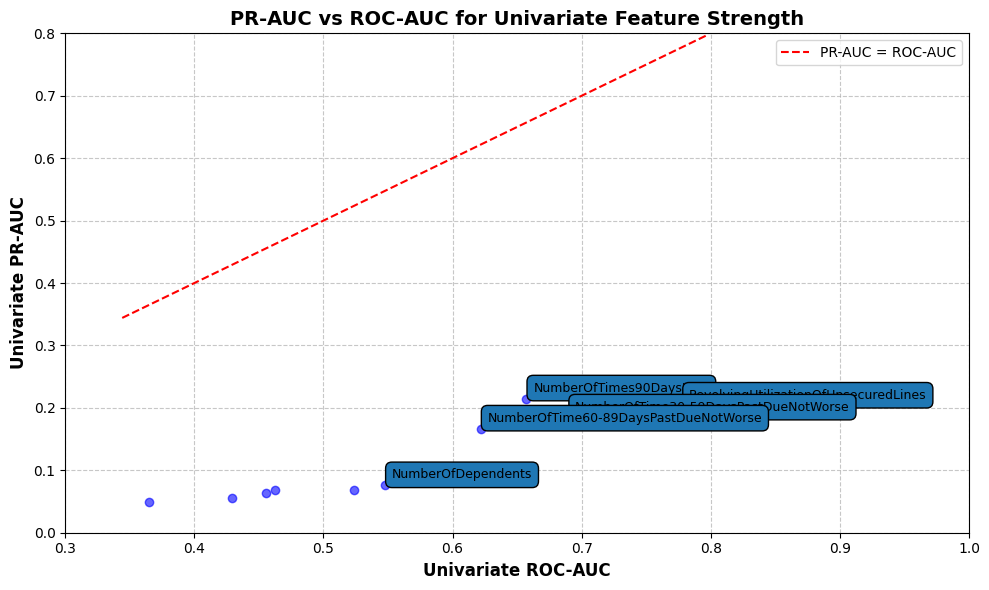

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Initialize dictionaries for both metrics
feature_pr_auc = {}
feature_roc_auc = {}
numeric_features = df.select_dtypes(include=[np.number]).columns.drop("SeriousDlqin2yrs")

for col in numeric_features:
    series = df[col].fillna(df[col].median())
    if series.nunique() <= 1:
        continue
    try:
        ranked_series = series.rank(pct=True, method='average')  # Handle ties with average
        pr_auc = average_precision_score(df["SeriousDlqin2yrs"], ranked_series)  # PR-AUC
        roc_auc = roc_auc_score(df["SeriousDlqin2yrs"], ranked_series)  # ROC-AUC
        feature_pr_auc[col] = pr_auc
        feature_roc_auc[col] = roc_auc
    except ValueError as e:
        print(f"{col}: Skipped due to {e}")
        continue

# Combine into a single DataFrame
feature_strength_df = pd.DataFrame({
    "Univariate PR-AUC": pd.Series(feature_pr_auc),
    "Univariate ROC-AUC": pd.Series(feature_roc_auc)
}).sort_values(by="Univariate PR-AUC", ascending=False)

# Display with styling
display(feature_strength_df.style.background_gradient(cmap="Blues", subset=["Univariate PR-AUC"])
                              .background_gradient(cmap="Greens", subset=["Univariate ROC-AUC"])
                              .format("{:.3f}"))

# Top 5 in a concise table with consistent formatting
print(f"\nTop 5 Predictive Features (PR-AUC and ROC-AUC) of {len(feature_strength_df)} total:")
display(feature_strength_df.head(5).style.format("{:.3f}"))

# Visualization: Scatter plot of PR-AUC vs ROC-AUC
plt.figure(figsize=(10, 6))
plt.scatter(feature_strength_df["Univariate ROC-AUC"], feature_strength_df["Univariate PR-AUC"], 
            color='blue', alpha=0.6)
plt.xlabel("Univariate ROC-AUC", fontsize=12, fontweight='bold')
plt.ylabel("Univariate PR-AUC", fontsize=12, fontweight='bold')
plt.title("PR-AUC vs ROC-AUC for Univariate Feature Strength", fontsize=14, fontweight='bold')

# Label top 5 features with boxed annotations
top_5_features = feature_strength_df.head(5).index
for feature in top_5_features:
    plt.annotate(feature, 
                 (feature_strength_df.loc[feature, "Univariate ROC-AUC"], 
                  feature_strength_df.loc[feature, "Univariate PR-AUC"]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.5"))

# Add a diagonal reference line (where PR-AUC = ROC-AUC) adjusted to visible range
xlim_min, xlim_max = plt.xlim()  # Get current x-axis limits
plt.plot([xlim_min, xlim_max], [xlim_min, xlim_max], color='red', linestyle='--', label='PR-AUC = ROC-AUC')

plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0.3, 1)
plt.ylim(0, 0.8)
plt.tight_layout()
plt.show()

Building on validated data, the Univariate Feature Strength analysis reveals that delinquency behavior and credit utilization remain the strongest predictors of default risk, while demographic and income-based variables show weaker direct influence.

- **Top Predictors Identified:**  
  - `NumberOfTimes90DaysLate` and `RevolvingUtilizationOfUnsecuredLines` emerge as the strongest predictors, with **ROC-AUC scores of ~0.66–0.78** and the highest **PR-AUC values (~0.20–0.22)**.  
  - Other delinquency-related features (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`) also perform well, reinforcing that **past delinquency history is the clearest signal of future default risk**.  

- **Weaker Predictors:**  
  - Features like `age`, `MonthlyIncome`, and `NumberOfOpenCreditLinesAndLoans` show **low PR-AUC (<0.07)** and **low ROC-AUC (<0.46)**.  
  - These features contribute little on their own, but may still add value through **interactions** (e.g., `income × debt ratio`) or **non-linear transformations**.  

- **PR-AUC vs. ROC-AUC Gap:**  
  - The scatter plot shows a consistent **gap between ROC-AUC and PR-AUC**.  
  - This reflects the **class imbalance problem**: while ROC-AUC suggests moderate separation between classes, PR-AUC reveals that features are less effective in correctly ranking the minority defaulters.  

- **Modeling Implications:**  
  - High-AUC features should be prioritized in early model iterations, especially in **tree-based models**.  
  - Low-AUC features may be dropped if redundant, or re-engineered into **interaction/binned variables** to improve predictive power.  

Overall, this analysis quantifies the relative strength of each feature, bridging exploratory insights with model design considerations and confirming which predictors warrant priority in the upcoming modeling phase.

---

## Key Takeaways from EDA

The EDA for the **Give Me Some Credit** dataset provided a clear understanding of data quality, feature behavior, and predictive potential. Each step built toward identifying the strongest signals for modeling and mitigating sources of bias or instability.

### 1. Data Overview & Structure
- The dataset is clean, well-structured, and free from missing values after preprocessing.
- Numeric features dominate, aligning well with modeling approaches such as logistic regression, tree-based ensembles, and gradient boosting.
- Initial descriptive statistics revealed **extreme variance** across several numeric features—particularly `DebtRatio`, `MonthlyIncome`, and `RevolvingUtilizationOfUnsecuredLines`—prompting deeper anomaly checks.

### 2. Class Distribution & Outlier Analysis
- **Severe class imbalance:** Only ~6–7% of records represent defaults (`SeriousDlqin2yrs = 1`), confirming this is a **highly imbalanced binary classification** problem.  
  → Modeling must prioritize **PR-AUC** as the main evaluation metric and apply class weighting or resampling (SMOTE/undersampling).
- **Outlier patterns:** Several features show heavy right skew and extreme values—`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, and `MonthlyIncome` in particular.  
  → Log transformation, winsorization, or capped binning will be applied to stabilize variance.
- **Anomalies and sentinels:**  
  - Zero-income records and sentinel delinquency values (`98+`) were detected.  
  - These require tailored handling—e.g., binary flags (`is_sentinel`), or capping (`min(original, 10)`) to prevent distortion in modeling.

### 3. Correlation & Redundancy
- **Strong pairwise correlations** among delinquency features (Pearson > 0.9) indicate partial redundancy, while moderate non-linear ties appear in Spearman correlations.  
- **VIF analysis** confirms multicollinearity clusters around delinquency variables, suggesting dimensionality reduction (e.g., PCA, feature grouping) may help stabilize linear models.  
- Overall, correlations validate that while most variables contribute unique information, **delinquency metrics may need consolidation** to prevent overfitting.

### 4. Feature-Focused Analysis
- **Class-Balanced KDEs & Bin-Wise Default Rates:**  
  Revealed intuitive, business-relevant risk patterns:
  - Default risk increases sharply at high utilization levels and extreme debt ratios.  
  - Income shows a non-monotonic relationship—risk is highest for the lowest deciles, stabilizing beyond mid-range income levels.  
  → These patterns justify engineered bins and non-linear transformations for risk-sensitive features.
- **Anomalies & Sentinel Values:**  
  Reconfirmed implausible records (e.g., age=0) and sentinel flags in delinquency counts. These will be cleaned or recoded to preserve modeling validity.
- **Univariate Feature Strength (AUC Ranking):**  
  - Top predictors: `NumberOfTimes90DaysLate`, `RevolvingUtilizationOfUnsecuredLines`, and other delinquency counts (PR-AUC ≈ 0.20–0.22).  
  - Weaker predictors like `MonthlyIncome` and `NumberOfOpenCreditLinesAndLoans` may still contribute through interactions.  
  → These insights directly inform feature prioritization and selection in modeling.

## Transition to Modeling

With EDA complete, the modeling phase will focus on translating these insights into a robust predictive framework:

1. **Data Preparation**
   - Apply log-scaling and capping for heavy-tailed variables.  
   - Encode sentinel flags and handle zero-income cases.  
   - Normalize or standardize numeric features where needed.
   - Perform PCA on correlated delinquency features to reduce dimensionality, targeting 95% explained variance.

2. **Class Imbalance Handling**
   - Use **class weights** or **resampling strategies** (e.g., SMOTE) to counter default rarity.  
   - Evaluate performance using **PR-AUC** and **Recall@K**, rather than accuracy or ROC-AUC.

3. **Feature Engineering**
   - Consolidate correlated delinquency features (e.g., aggregate score or PCA component).  
   - Create interaction terms (e.g., `DebtRatio × MonthlyIncome`).  
   - Explore non-linear transformations (log, bins, quantiles) for skewed variables.

4. **Modeling Strategy**
   - Begin with interpretable baselines (e.g., Logistic Regression with regularization).  
   - Compare against non-linear models (Random Forest, XGBoost, or LightGBM) for complex feature interactions.  
   - Prioritize explainability and stability to support credit-risk compliance standards.

5. **Evaluation & Validation**
   - Use stratified k-fold cross-validation to maintain class proportions.  
   - Focus on PR-AUC, F1-score (for defaulters), and calibration curves to assess probability accuracy.
   - Test statistical significance with Kolmogorov-Smirnov for class distribution differences.



The EDA uncovered critical data behaviors—imbalanced classes, strong delinquency signals, outliers, and multicollinearity—that will shape every modeling decision.  
The next step translates these findings into a structured, bias-aware, and performance-oriented predictive model for default risk classification.